# Ablation Study BERT-моделей

Систематическая оценка влияния вариантов текста, порога классификации,
калибровки вероятностей и анализа ошибок на качество классификации спама.

Ноутбук выполняет серию экспериментов:

1. **Сравнение вариантов текста** — raw / normalized / preprocessed для RuBERT-tiny и RuBERT-tiny2
2. **Оптимизация порога** — влияние порога классификации на precision и recall
3. **Калибровка вероятностей** — TemperatureScaler и оценка Brier score
4. **Анализ ошибок** — категоризация FP и FN по типам

Все эксперименты проводятся на внешнем тестовом датасете `test_preprocessed.csv`.

## Импорты и настройка

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    pipeline,
)

try:
    _project_root = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    _cwd = os.getcwd()
    _project_root = _cwd
    while _project_root != '/' and not os.path.isdir(os.path.join(_project_root, 'src')):
        _project_root = os.path.dirname(_project_root)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

from src.models.transformer import bert_predict_batch, is_mostly_cyrillic, TemperatureScaler
from src.evaluation.metrics import optimize_threshold
from src.config import PROCESSED_DIR, MODELS_DIR

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## Загрузка тестовых данных

Загружается `test_preprocessed.csv` — внешний тестовый датасет, подготовленный в ноутбуке 01d. Не пересекается с обучающей выборкой.

In [2]:
df_test = pd.read_csv(PROCESSED_DIR / 'test_preprocessed.csv', index_col=0)
df_test = df_test.dropna(subset=['text_preprocessed']).reset_index(drop=True)

print(f'Размер тестовой выборки: {len(df_test)}')

class_counts = df_test['label'].value_counts()
print(f'Ham (0): {class_counts.get(0, 0)}')
print(f'Spam (1): {class_counts.get(1, 0)}')
print(f'Дисбаланс: {class_counts.get(0, 0) / max(class_counts.get(1, 1), 1):.1f}x')

Размер тестовой выборки: 41369
Ham (0): 22625
Spam (1): 18744
Дисбаланс: 1.2x


## Загрузка BERT-моделей

Загружаются 6 дообученных BERT-моделей:
- RuBERT-tiny: raw, norm, p
- RuBERT-tiny2: raw, norm, p

Для каждой модели указывается вариант текста, на котором она обучалась, и порог классификации из ноутбука 05.

In [3]:
BERT_VARIANTS = [
    {'label': 'rubert_tiny2_raw', 'dir': 'finetuned_rubert_tiny2_raw', 'text_col': 'text_raw', 'threshold': 0.856187},
    {'label': 'rubert_tiny2_norm', 'dir': 'finetuned_rubert_tiny2_norm', 'text_col': 'text_normalized', 'threshold': 0.815507},
    {'label': 'rubert_tiny2_p', 'dir': 'finetuned_rubert_tiny2_p', 'text_col': 'text_preprocessed', 'threshold': 0.951362},
    {'label': 'rubert_tiny_raw', 'dir': 'finetuned_rubert_tiny_raw', 'text_col': 'text_raw', 'threshold': 0.814425},
    {'label': 'rubert_tiny_norm', 'dir': 'finetuned_rubert_tiny_norm', 'text_col': 'text_normalized', 'threshold': 0.802793},
    {'label': 'rubert_tiny_p', 'dir': 'finetuned_rubert_tiny_p', 'text_col': 'text_preprocessed', 'threshold': 0.939308},
]

bert_classifiers = {}
for variant in BERT_VARIANTS:
    model_path = str(MODELS_DIR / variant['dir'])
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    bert_classifiers[variant['label']] = pipeline(
        'text-classification',
        model=model,
        tokenizer=tokenizer,
        device='cpu',
        truncation=True,
        max_length=256,
    )
    print(f'Загружена модель: {variant["label"]}')

Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

Загружена модель: rubert_tiny2_raw


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

Загружена модель: rubert_tiny2_norm


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

...

Загружена модель: rubert_tiny_raw


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

Загружена модель: rubert_tiny_norm


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

Загружена модель: rubert_tiny_p


## Получение предсказаний

Для каждой модели выполняется предсказание на соответствующем варианте текста. Сохраняются метки и вероятности класса spam.

In [4]:
test_labels = df_test['label'].values

bert_preds_all = {}
bert_proba_all = {}

for variant in BERT_VARIANTS:
    label = variant['label']
    texts = df_test[variant['text_col']].astype(str).tolist()
    results = bert_predict_batch(
        texts,
        bert_classifiers[label],
        threshold=variant['threshold'],
        batch_size=16,
    )
    bert_preds_all[label] = np.array([r[0] for r in results])
    bert_proba_all[label] = np.array([r[1][1] for r in results])
    spam_count = bert_preds_all[label].sum()
    ham_count = (bert_preds_all[label] == 0).sum()
    print(f'{label}: spam={spam_count}, ham={ham_count}')

rubert_tiny2_raw: spam=16900, ham=24469
rubert_tiny2_norm: spam=16967, ham=24402
rubert_tiny2_p: spam=16987, ham=24382
rubert_tiny_raw: spam=17054, ham=24315
rubert_tiny_norm: spam=16936, ham=24433
rubert_tiny_p: spam=16887, ham=24482


## Эксперимент 1: Сравнение вариантов текста

Для каждой из 6 BERT-моделей вычисляются метрики на внешнем тесте: accuracy, precision (spam), recall (spam), F1 (spam), F1-macro, ROC-AUC, PR-AUC. Результаты сортируются по F1-macro.

In [5]:
def compute_metrics(y_true, y_pred, y_proba):
    """Вычисляет метрики классификации для одной модели."""
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision_spam': float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
        'recall_spam': float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)),
        'f1_spam': float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)),
        'f1_macro': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'roc_auc': float(roc_auc_score(y_true, y_proba)),
        'pr_auc': float(average_precision_score(y_true, y_proba)),
    }

In [6]:
results = []

for variant in BERT_VARIANTS:
    label = variant['label']
    results.append({
        'model': label,
        **compute_metrics(test_labels, bert_preds_all[label], bert_proba_all[label]),
    })

results_df = pd.DataFrame(results).sort_values('f1_macro', ascending=False).reset_index(drop=True)
results_df

,model,accuracy,precision_spam,recall_spam,f1_spam,f1_macro,roc_auc,pr_auc
0,rubert_tiny_raw,0.958181,0.998827,0.908771,0.951673,0.957409,0.998135,0.997925
1,rubert_tiny2_p,0.956562,0.998823,0.905196,0.949708,0.955740,0.998726,0.998663
2,rubert_tiny2_norm,0.955740,0.998409,0.903756,0.948727,0.954896,0.997392,0.997432
3,rubert_tiny2_raw,0.954507,0.998876,0.900608,0.947200,0.953619,0.998230,0.998098
4,rubert_tiny_p,0.954289,0.998993,0.900021,0.946928,0.953393,0.997870,0.997876
5,rubert_tiny_norm,0.953927,0.997107,0.900928,0.946581,0.953039,0.996961,0.996729


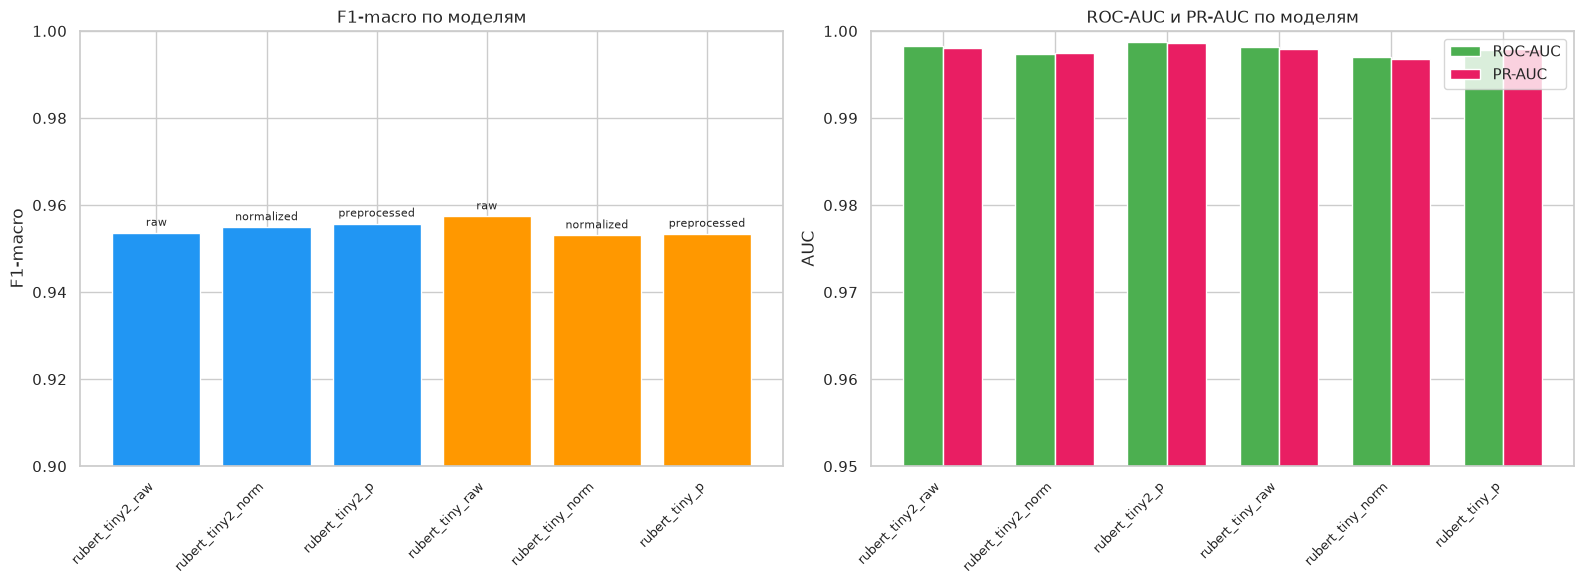

In [7]:
model_names = [v['label'] for v in BERT_VARIANTS]
variants_text = [v['text_col'].replace('text_', '') for v in BERT_VARIANTS]
model_types = ['tiny2' if 'tiny2' in v['label'] else 'tiny' for v in BERT_VARIANTS]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
x = np.arange(len(model_names))
bars = ax.bar(x, [results_df.set_index('model').loc[m, 'f1_macro'] for m in model_names],
              color=['#2196F3' if t == 'tiny2' else '#FF9800' for t in model_types])
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('F1-macro')
ax.set_title('F1-macro по моделям')
ax.set_ylim(0.9, 1.0)
for bar, vt in zip(bars, variants_text):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            vt, ha='center', va='bottom', fontsize=8)

ax = axes[1]
width = 0.35
roc_vals = [results_df.set_index('model').loc[m, 'roc_auc'] for m in model_names]
pr_vals = [results_df.set_index('model').loc[m, 'pr_auc'] for m in model_names]
ax.bar(x - width / 2, roc_vals, width, label='ROC-AUC', color='#4CAF50')
ax.bar(x + width / 2, pr_vals, width, label='PR-AUC', color='#E91E63')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('AUC')
ax.set_title('ROC-AUC и PR-AUC по моделям')
ax.set_ylim(0.95, 1.0)
ax.legend()

plt.tight_layout()
plt.show()

## Эксперимент 2: Оптимизация порога классификации

Сравниваются метрики при пороге по умолчанию (0.5) и оптимизированном пороге (максимизация Precision при Recall >= 0.90) для каждой модели.

In [8]:
thr_results = []

for variant in BERT_VARIANTS:
    label = variant['label']
    proba = bert_proba_all[label]

    preds_default = (proba >= 0.5).astype(int)
    m_default = compute_metrics(test_labels, preds_default, proba)

    thr_opt = optimize_threshold(test_labels, proba, target_recall=0.90)
    preds_opt = (proba >= thr_opt['threshold']).astype(int)
    m_opt = compute_metrics(test_labels, preds_opt, proba)

    thr_results.append({
        'model': label,
        'thr_default': 0.5,
        'precision_default': m_default['precision_spam'],
        'recall_default': m_default['recall_spam'],
        'f1_default': m_default['f1_spam'],
        'thr_optimized': thr_opt['threshold'],
        'precision_opt': m_opt['precision_spam'],
        'recall_opt': m_opt['recall_spam'],
        'f1_opt': m_opt['f1_spam'],
        'delta_precision': m_opt['precision_spam'] - m_default['precision_spam'],
        'delta_recall': m_opt['recall_spam'] - m_default['recall_spam'],
    })

thr_df = pd.DataFrame(thr_results)
thr_df

,model,thr_default,precision_default,recall_default,f1_default,thr_optimized,precision_opt,recall_opt,f1_opt,delta_precision,delta_recall
0,rubert_tiny2_raw,0.5,0.996497,0.956199,0.975932,0.856187,0.998876,0.900662,0.947230,0.002379,-0.055538
1,rubert_tiny2_norm,0.5,0.994281,0.955292,0.974397,0.815507,0.998409,0.903809,0.948757,0.004128,-0.051483
2,rubert_tiny2_p,0.5,0.995142,0.972578,0.983730,0.951362,0.998823,0.905250,0.949737,0.003681,-0.067328
3,rubert_tiny_raw,0.5,0.994814,0.951825,0.972845,0.814425,0.998827,0.908771,0.951673,0.004013,-0.043054
4,rubert_tiny_norm,0.5,0.993549,0.936780,0.964330,0.802793,0.997107,0.900928,0.946581,0.003557,-0.035851
5,rubert_tiny_p,0.5,0.994166,0.963615,0.978652,0.939308,0.998993,0.900075,0.946958,0.004828,-0.063540


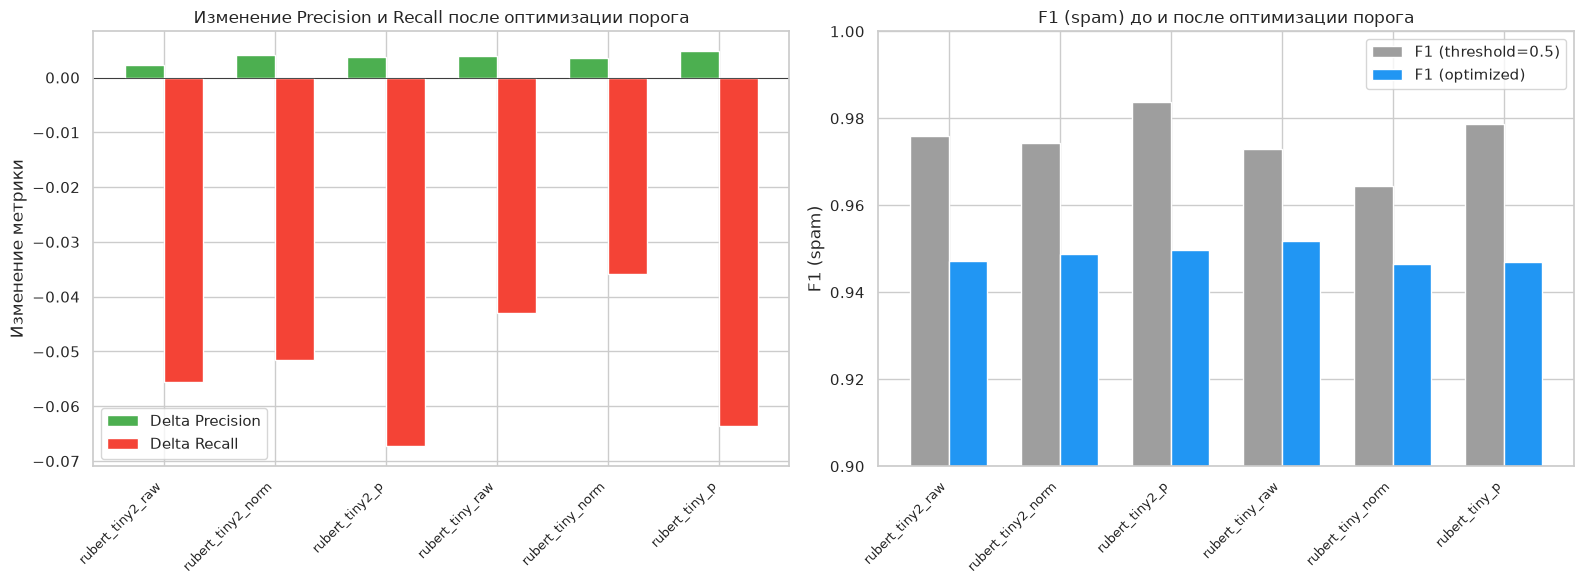

In [9]:
model_names = [v['label'] for v in BERT_VARIANTS]
x = np.arange(len(model_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
delta_prec = [thr_df.set_index('model').loc[m, 'delta_precision'] for m in model_names]
delta_rec = [thr_df.set_index('model').loc[m, 'delta_recall'] for m in model_names]
ax.bar(x - width / 2, delta_prec, width, label='Delta Precision', color='#4CAF50')
ax.bar(x + width / 2, delta_rec, width, label='Delta Recall', color='#F44336')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Изменение метрики')
ax.set_title('Изменение Precision и Recall после оптимизации порога')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.legend()

ax = axes[1]
f1_def = [thr_df.set_index('model').loc[m, 'f1_default'] for m in model_names]
f1_opt = [thr_df.set_index('model').loc[m, 'f1_opt'] for m in model_names]
ax.bar(x - width / 2, f1_def, width, label='F1 (threshold=0.5)', color='#9E9E9E')
ax.bar(x + width / 2, f1_opt, width, label='F1 (optimized)', color='#2196F3')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('F1 (spam)')
ax.set_title('F1 (spam) до и после оптимизации порога')
ax.set_ylim(0.9, 1.0)
ax.legend()

plt.tight_layout()
plt.show()

## Эксперимент 3: Калибровка вероятностей

Применяется TemperatureScaler для калибровки вероятностей каждой модели. Тестовый датасет разделяется на calibration set (30%) и evaluation set (70%). Brier score сравнивается до и после калибровки.

In [11]:
from sklearn.model_selection import train_test_split

calib_indices, eval_indices = train_test_split(
    np.arange(len(test_labels)),
    test_size=0.7,
    random_state=RANDOM_STATE,
    stratify=test_labels,
)

calib_results = []

for variant in BERT_VARIANTS:
    label = variant['label']
    model_path = str(MODELS_DIR / variant['dir'])
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    model.eval()

    texts_calib = df_test[variant['text_col']].astype(str).iloc[calib_indices].tolist()
    texts_eval = df_test[variant['text_col']].astype(str).iloc[eval_indices].tolist()
    labels_calib = torch.tensor(test_labels[calib_indices], dtype=torch.long)
    labels_eval = test_labels[eval_indices]

    def get_logits(texts, batch_size=16):
        all_logits = []
        with torch.no_grad():
            for i in range(0, len(texts), batch_size):
                batch = texts[i:i + batch_size]
                inputs = tokenizer(batch, padding=True, truncation=True, max_length=256, return_tensors='pt')
                outputs = model(**inputs)
                all_logits.append(outputs.logits)
        return torch.cat(all_logits, dim=0)

    logits_calib = get_logits(texts_calib)
    logits_eval = get_logits(texts_eval)

    proba_before = torch.softmax(logits_eval, dim=1)[:, 1].numpy()
    brier_before = brier_score_loss(labels_eval, proba_before)

    scaler = TemperatureScaler()
    scaler.fit(logits_calib, labels_calib)

    scaled_logits_eval = scaler(logits_eval)
    proba_after = torch.softmax(scaled_logits_eval, dim=1)[:, 1].detach().numpy()
    brier_after = brier_score_loss(labels_eval, proba_after)

    calib_results.append({
        'model': label,
        'brier_before': float(brier_before),
        'brier_after': float(brier_after),
        'delta_brier': float(brier_after - brier_before),
        'temperature': float(scaler.temperature.item()),
    })

    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

calib_df = pd.DataFrame(calib_results)
calib_df

Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

,model,brier_before,brier_after,delta_brier,temperature
0,rubert_tiny2_raw,0.018325,0.018326,0.000001,0.991232
1,rubert_tiny2_norm,0.018969,0.018693,-0.000276,0.801615
2,rubert_tiny2_p,0.012116,0.012211,0.000095,0.879316
3,rubert_tiny_raw,0.019550,0.019536,-0.000014,0.831353
4,rubert_tiny_norm,0.025982,0.025848,-0.000134,1.044630
5,rubert_tiny_p,0.015328,0.015429,0.000102,0.905092


Визуализация Brier score до и после калибровки.

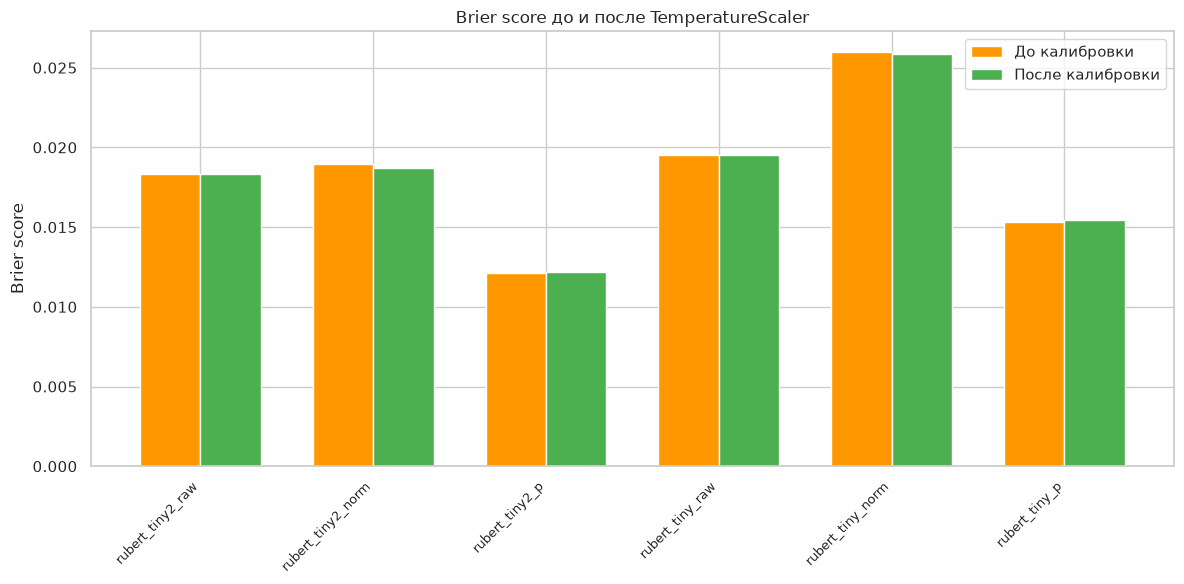

In [12]:
model_names = [v['label'] for v in BERT_VARIANTS]
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

brier_before = [calib_df.set_index('model').loc[m, 'brier_before'] for m in model_names]
brier_after = [calib_df.set_index('model').loc[m, 'brier_after'] for m in model_names]

ax.bar(x - width / 2, brier_before, width, label='До калибровки', color='#FF9800')
ax.bar(x + width / 2, brier_after, width, label='После калибровки', color='#4CAF50')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Brier score')
ax.set_title('Brier score до и после TemperatureScaler')
ax.legend()

plt.tight_layout()
plt.show()

## Эксперимент 4: Анализ ошибок

Для каждой модели вычисляются количества false positives и false negatives. Ошибки категоризируются по типам: non_russian, short_with_contact, legitimate_job, telegram_link, contains_link, near_boundary, other.

In [13]:
SPAM_MARKERS = [
    'казино', 'выигрыш', 'выиграл', 'депозит', 'криптовалют', 'usdt',
    'bitcoin', 'ставка', 'букмекер', 'бонус', 'заработок', 'доход',
    'пирамид', 'инвест', 'forex', 'трейдинг', 'обнал', 'отмыв',
]

JOB_MARKERS = [
    'вакансия', 'требуется', 'работа', 'смена', 'зарплата',
    'оплата', 'нанят', 'сотрудник', 'раздача', 'касса',
]

CONTACT_PATTERNS = [
    'пиши в лс', 'пишите в лс', 'пиши в личку', 'пишите в личку',
    'напиши в лс', 'напишите в лс', 'напиши в личку', 'напишите в личку',
    'в личку', 'в лс', 'в личные сообщения',
]

In [14]:
def categorize_error(text, proba_spam):
    """Определяет категорию ошибки по тексту и уверенности модели."""
    text_lower = text.lower()
    has_spam_marker = any(m in text_lower for m in SPAM_MARKERS)

    if not is_mostly_cyrillic(text):
        return 'non_russian'

    if len(text) <= 50 and any(p in text_lower for p in CONTACT_PATTERNS):
        return 'short_with_contact'

    if any(m in text_lower for m in JOB_MARKERS) and not has_spam_marker:
        return 'legitimate_job'

    if ('t.me' in text_lower or '@' in text) and not has_spam_marker:
        return 'telegram_link'

    if ('http' in text_lower or 'www.' in text_lower) and not has_spam_marker:
        return 'contains_link'

    if 0.4 <= proba_spam <= 0.6:
        return 'near_boundary'

    return 'other'

In [15]:
from collections import Counter

CATEGORY_ORDER = [
    'non_russian', 'short_with_contact', 'legitimate_job',
    'telegram_link', 'contains_link', 'near_boundary', 'other',
]

error_summary = []
error_categories = {}

for variant in BERT_VARIANTS:
    label = variant['label']
    preds = bert_preds_all[label]
    proba = bert_proba_all[label]
    text_col = variant['text_col']
    texts = df_test[text_col].astype(str).tolist()

    fp_mask = (test_labels == 0) & (preds == 1)
    fn_mask = (test_labels == 1) & (preds == 0)
    fp_indices = np.where(fp_mask)[0]
    fn_indices = np.where(fn_mask)[0]

    fp_cats = [categorize_error(texts[idx], proba[idx]) for idx in fp_indices]
    fn_cats = [categorize_error(texts[idx], proba[idx]) for idx in fn_indices]

    error_categories[label] = {
        'fp_categories': fp_cats,
        'fn_categories': fn_cats,
    }

    error_summary.append({
        'model': label,
        'FP': int(fp_mask.sum()),
        'FN': int(fn_mask.sum()),
        'total_errors': int(fp_mask.sum() + fn_mask.sum()),
    })

error_df = pd.DataFrame(error_summary).sort_values('total_errors')
error_df

,model,FP,FN,total_errors
3,rubert_tiny_raw,20,1710,1730
2,rubert_tiny2_p,20,1777,1797
1,rubert_tiny2_norm,27,1804,1831
0,rubert_tiny2_raw,19,1863,1882
5,rubert_tiny_p,17,1874,1891
4,rubert_tiny_norm,49,1857,1906


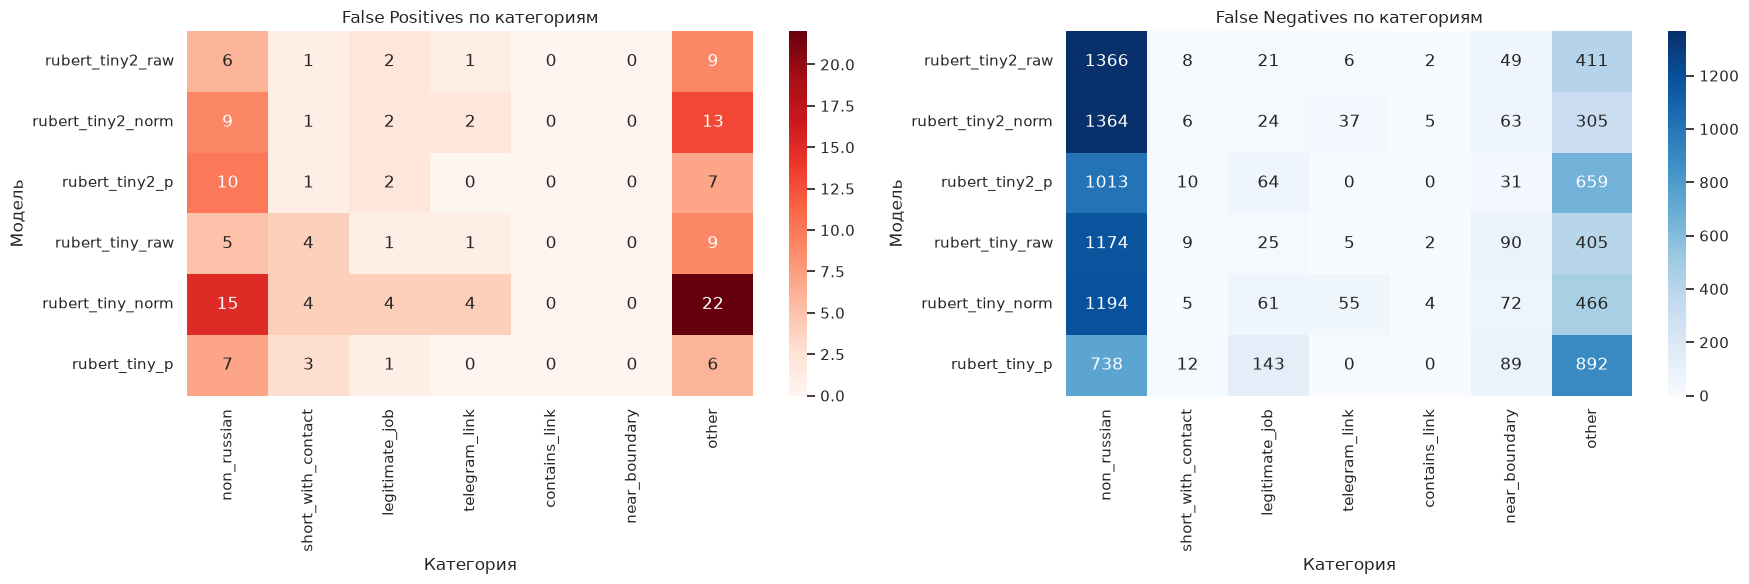

In [16]:
model_names = [v['label'] for v in BERT_VARIANTS]

fp_matrix = []
fn_matrix = []

for label in model_names:
    fp_counts = Counter(error_categories[label]['fp_categories'])
    fn_counts = Counter(error_categories[label]['fn_categories'])
    fp_matrix.append([fp_counts.get(cat, 0) for cat in CATEGORY_ORDER])
    fn_matrix.append([fn_counts.get(cat, 0) for cat in CATEGORY_ORDER])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(
    fp_matrix,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=CATEGORY_ORDER,
    yticklabels=model_names,
    ax=axes[0],
)
axes[0].set_title('False Positives по категориям')
axes[0].set_xlabel('Категория')
axes[0].set_ylabel('Модель')

sns.heatmap(
    fn_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CATEGORY_ORDER,
    yticklabels=model_names,
    ax=axes[1],
)
axes[1].set_title('False Negatives по категориям')
axes[1].set_xlabel('Категория')
axes[1].set_ylabel('Модель')

plt.tight_layout()
plt.show()

## Сводная таблица и выводы

Сводка результатов по всем экспериментам: лучшая модель по F1-macro, влияние варианта текста, эффект оптимизации порога, улучшение калибровки и топ категории ошибок.

In [17]:
best_f1 = results_df.iloc[0]
best_pr_auc = results_df.loc[results_df['pr_auc'].idxmax()]

print('Лучшие модели:')
print(f'  По F1-macro:  {best_f1["model"]} (F1-macro={best_f1["f1_macro"]:.4f})')
print(f'  По PR-AUC:    {best_pr_auc["model"]} (PR-AUC={best_pr_auc["pr_auc"]:.4f})')

print('\nВлияние варианта текста (усреднённые метрики по tiny и tiny2):')
for text_col in ['text_raw', 'text_normalized', 'text_preprocessed']:
    variant_labels = [v['label'] for v in BERT_VARIANTS if v['text_col'] == text_col]
    avg_f1 = np.mean([results_df.set_index('model').loc[m, 'f1_macro'] for m in variant_labels])
    avg_pr = np.mean([results_df.set_index('model').loc[m, 'pr_auc'] for m in variant_labels])
    short_name = text_col.replace('text_', '')
    print(f'  {short_name:15s}: F1-macro={avg_f1:.4f}, PR-AUC={avg_pr:.4f}')

print('\nВлияние оптимизации порога:')
avg_delta_prec = thr_df['delta_precision'].mean()
avg_delta_rec = thr_df['delta_recall'].mean()
print(f'  Средний gain Precision: {avg_delta_prec:+.4f}')
print(f'  Средний loss Recall:    {avg_delta_rec:+.4f}')

print('\nКалибровка (TemperatureScaler):')
avg_brier_before = calib_df['brier_before'].mean()
avg_brier_after = calib_df['brier_after'].mean()
print(f'  Средний Brier до:  {avg_brier_before:.4f}')
print(f'  Средний Brier после: {avg_brier_after:.4f}')
print(f'  Среднее улучшение:  {avg_brier_before - avg_brier_after:+.4f}')

print('\nТоп-3 категории ошибок (в среднем по всем моделям):')
all_fn_cats = []
for label in model_names:
    all_fn_cats.extend(error_categories[label]['fn_categories'])
fn_counter = Counter(all_fn_cats)
for cat, count in fn_counter.most_common(3):
    print(f'  {cat}: {count}')

Лучшие модели:
  По F1-macro:  rubert_tiny_raw (F1-macro=0.9574)
  По PR-AUC:    rubert_tiny2_p (PR-AUC=0.9987)

Влияние варианта текста (усреднённые метрики по tiny и tiny2):
  raw            : F1-macro=0.9555, PR-AUC=0.9980
  normalized     : F1-macro=0.9540, PR-AUC=0.9971
  preprocessed   : F1-macro=0.9546, PR-AUC=0.9983

Влияние оптимизации порога:
  Средний gain Precision: +0.0038
  Средний loss Recall:    -0.0528

Калибровка (TemperatureScaler):
  Средний Brier до:  0.0184
  Средний Brier после: 0.0183
  Среднее улучшение:  +0.0000

Топ-3 категории ошибок (в среднем по всем моделям):
  non_russian: 6849
  other: 3138
  near_boundary: 394
